# Exercise 2: simulating the income distribution

The model is implemented in the module `incomesim.py`, which is imported below. This notebook calls the functions in the module, shows the figures and comments on the results.

In [112]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

import incomesim as sim

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Exercise 2.1

All parameters are defined at the top of `incomesim.py`

In [113]:
rng = np.random.default_rng(sim.seed)

psi, education_level_i, S_e_i, uniforms = sim.draw_shocks(rng)

print('All global variables and shocks are defined')
print(f'mean value of psi: {psi.mean():.2f}')

All global variables and shocks are defined
mean value of psi: 1.00


## Excercise 2.2

### 2.2.1

Before using the simulation we check it: the education shares should match $p_e$, and the unemployment rate should be close to the steady-state value $\sigma/(\sigma+\lambda)$.

In [114]:
print('Comparing education shares to p_e:')
sim.check_education_shares(education_level_i)

Comparing education shares to p_e:
Share short  0.3996 (target 0.4)
Share medium 0.3503 (target 0.35)
Share long   0.2501 (target 0.25)


In [115]:
employed = sim.simulate_employment(S_e_i, uniforms)

t_values = [1, 5, 8, 10, 20, 30, 40, sim.n_years - 1]
sim.check_unemployment_rate(employed, S_e_i, t_values)

Comparing unemployment rate to theoretical:
t = 1 (age 19): unemployment rate = 1.0000
t = 5 (age 23): unemployment rate = 0.3525
t = 8 (age 26): unemployment rate = 0.0888
t = 10 (age 28): unemployment rate = 0.0784
t = 20 (age 38): unemployment rate = 0.0771
t = 30 (age 48): unemployment rate = 0.0757
t = 40 (age 58): unemployment rate = 0.0767
t = 46 (age 64): unemployment rate = 0.0758

Theoretical steady-state unemployment rate: sigma/(sigma+lam) = 0.0769


The unemployment rate is high in the first years because everybody enters the labor market as unemployed but then converges towards the steady state.

### 2.2.2

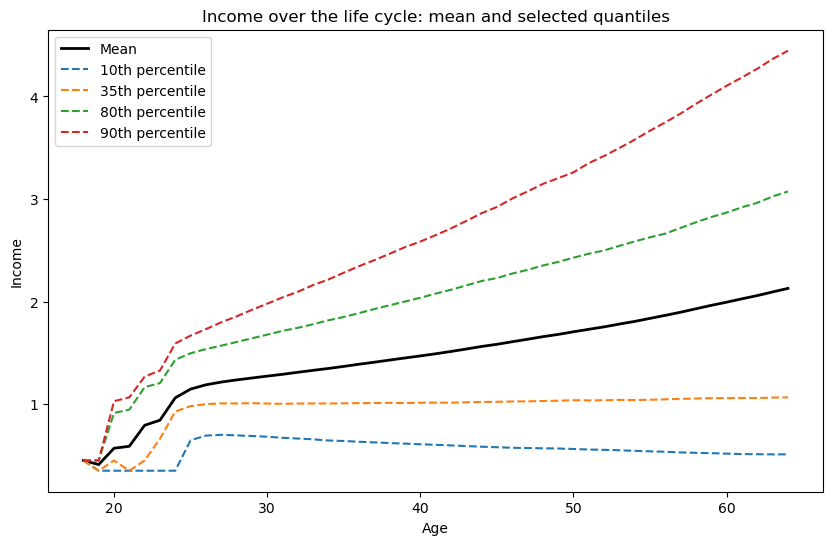

In [116]:
mean_income = income.mean(axis=0)

p10 = np.percentile(income, 10, axis=0)
p35 = np.percentile(income, 35, axis=0)
p80 = np.percentile(income, 80, axis=0)
p90 = np.percentile(income, 90, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(sim.ages, mean_income, label='Mean', color='black', linewidth=2)
plt.plot(sim.ages, p10, label='10th percentile', linestyle='--')
plt.plot(sim.ages, p35, label='35th percentile', linestyle='--')
plt.plot(sim.ages, p80, label='80th percentile', linestyle='--')
plt.plot(sim.ages, p90, label='90th percentile', linestyle='--')

plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Income over the life cycle: mean and selected quantiles')
plt.legend()
plt.show()

The figure shows the mean income and four percentiles over the life cycle.

### 2.2.3

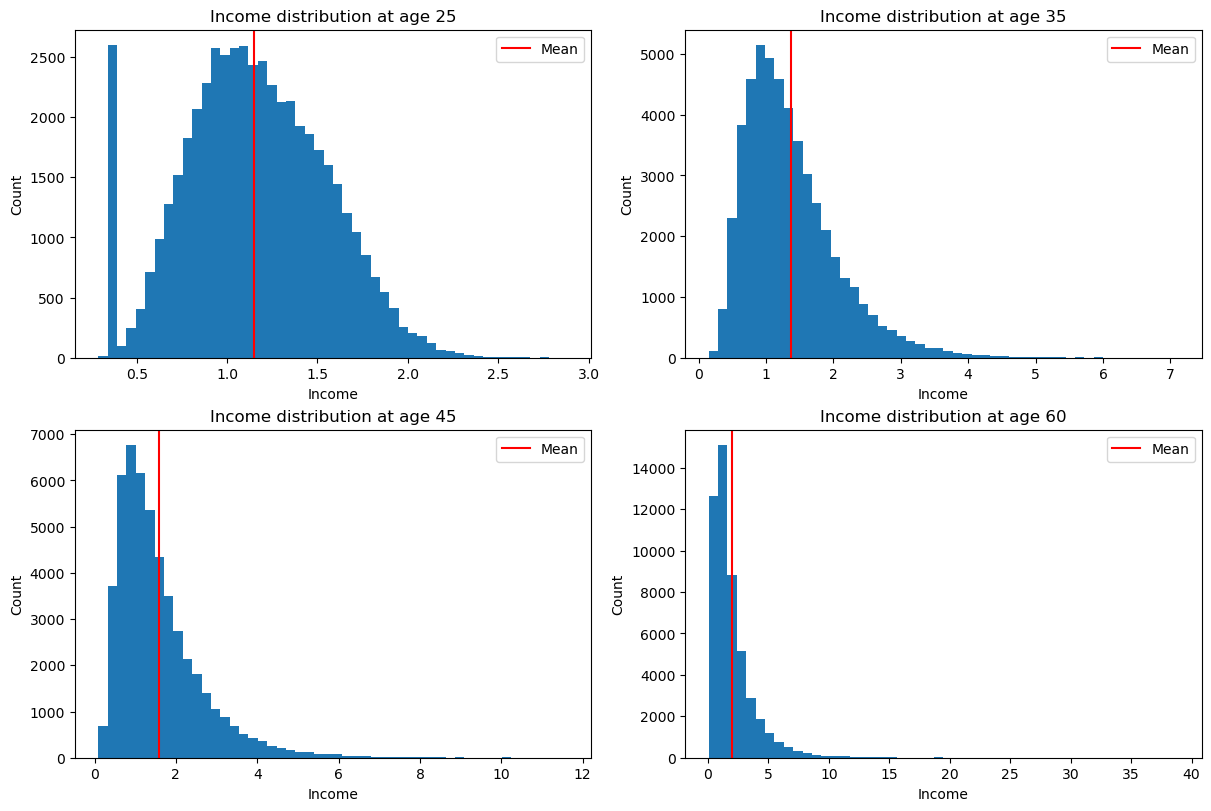

In [117]:
ages_plot = [25, 35, 45, 60]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout='constrained')
axes = axes.flatten()

for idx, age in enumerate(ages_plot):
    t = age - sim.age_start  # convert age to the period index
    axes[idx].hist(income[:, t], bins=50)
    axes[idx].axvline(income[:, t].mean(), color='red', label='Mean')
    axes[idx].set_title(f'Income distribution at age {age}')
    axes[idx].set_xlabel('Income')
    axes[idx].set_ylabel('Count')
    axes[idx].legend()

plt.show()

The plot shows that as time passes, the histograms shrink in size. This
likely happens because the three groups each converge against individual
income levels. However, while the histograms shrink in size, the relative
difference between incomes, i.e. the level of inequality, seems to
increase.

## Exercise 2.3

The function `gini_coefficient` is tested on two distributions where the
answer is known: the uniform distribution on $[0,1]$, where the Gini
coefficient is exactly $1/3$, and the lognormal distribution, where it is
$2\Phi(s/\sqrt{2})-1$.

In [118]:
gini_full_sample = sim.gini_coefficient(income.flatten())
print(f'Gini coefficient (FULL SAMPLE, all ages pooled): '
      f'{gini_full_sample:.4f}')

# uniform distribution
uniform_sample = rng.uniform(0, 1, 100_000)
gini_uniform = sim.gini_coefficient(uniform_sample)
print(f'Gini coefficient (UNIFORM TEST): {gini_uniform:.4f} '
      f'(theoretical: {1/3:.4f})')

# lognormal distribution
s = 2
lognormal_sample = rng.lognormal(0, s, size=100_000)
gini_lognormal = sim.gini_coefficient(lognormal_sample)
theoretical_lognormal = sim.gini_lognormal(s)
print(f'Gini coefficient (LOGNORMAL TEST, s={s}): {gini_lognormal:.4f} '
      f'(theoretical: {theoretical_lognormal:.4f})')

Gini coefficient (FULL SAMPLE, all ages pooled): 0.3742
Gini coefficient (UNIFORM TEST): 0.3339 (theoretical: 0.3333)
Gini coefficient (LOGNORMAL TEST, s=2): 0.8438 (theoretical: 0.8427)


### 2.3.1

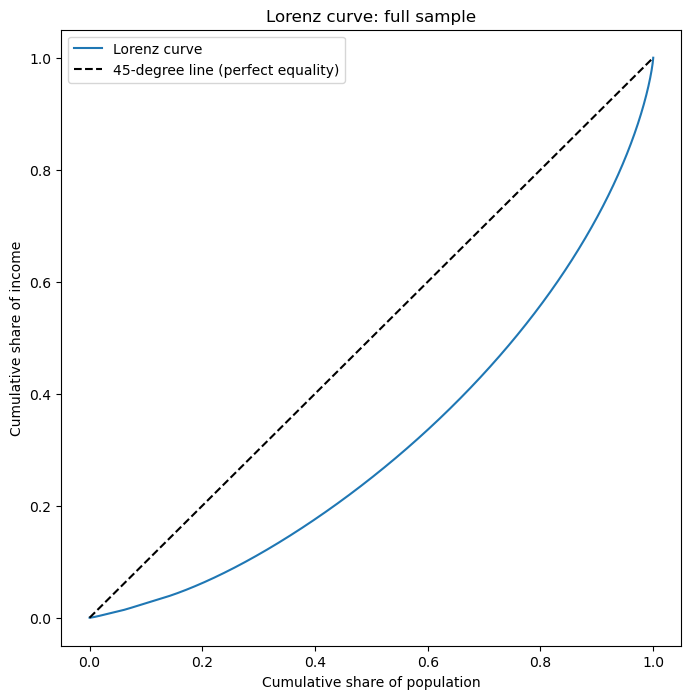

In [119]:
population_share, cumulative_income_share = sim.lorenz_curve(income.flatten())

plt.figure(figsize=(8, 8))
plt.plot(population_share, cumulative_income_share, label='Lorenz curve')
plt.plot([0, 1], [0, 1], label='45-degree line (perfect equality)',linestyle='--', color='black')

plt.xlabel('Cumulative share of population')
plt.ylabel('Cumulative share of income')
plt.title('Lorenz curve: full sample')
plt.legend()
plt.show()

### 2.3.2

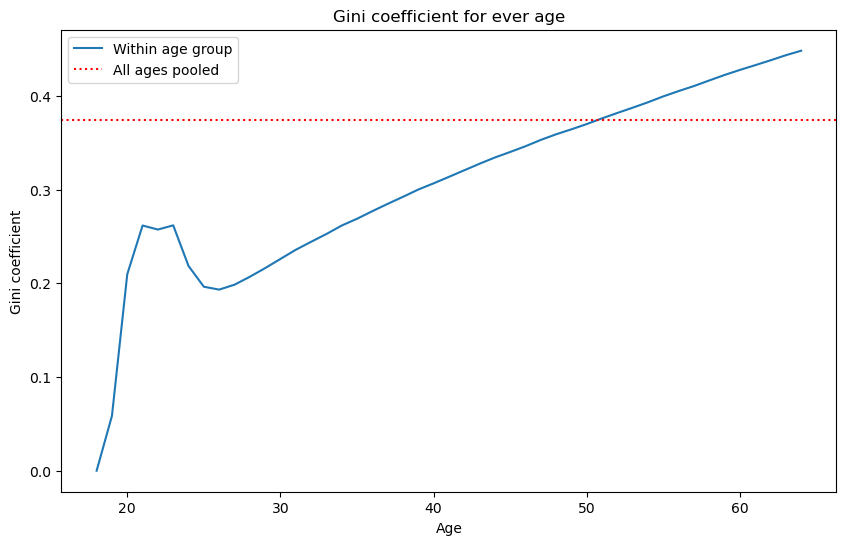

In [127]:
gini_by_age_baseline = sim.gini_by_age(income)

plt.figure(figsize=(10, 6))
plt.plot(sim.ages, gini_by_age_baseline, label='Within age group')
plt.axhline(gini_full_sample, color='red', linestyle=':', label='All ages pooled')
plt.xlabel('Age')
plt.ylabel('Gini coefficient')
plt.title('Gini coefficient for ever age')
plt.legend()
plt.show()

The graph shows that inequality increases with age due to differences in human capital accumulation. Thus, for some age groups the Gini coefficient is larger and for some smaller than for the entire population.

## 2.4
All four scenarios reuse `simulate_employment` and `simulate_income` as in the baseline case, but in each of the scenarios, parameter values are changed.

In [ ]:
# No educational differences:
S_e_avg, h_e0_avg, delta_e_avg = sim.average_education_parameters()
S_e_i_no_education = np.full(sim.N, S_e_avg)

employed_no_education = sim.simulate_employment(S_e_i_no_education, uniforms)
income_no_education, _ = sim.simulate_income(S_e_i_no_education, employed_no_education, psi, 
                                             education_level_i,h_e0=h_e0_avg, delta_e=delta_e_avg)

# No shocks to human capital: 
psi_no_shocks = np.ones((sim.N, sim.n_years))
income_no_shocks, _ = sim.simulate_income(S_e_i, employed, psi_no_shocks, education_level_i)

# No depreciation while unemployed:
income_no_depreciation, _ = sim.simulate_income(S_e_i, employed, psi,education_level_i, delta=0.0)

# No unemployment:
employed_no_unemployment = sim.employment_always_employed(S_e_i)
income_no_unemployment, _ = sim.simulate_income(
    S_e_i, employed_no_unemployment, psi, education_level_i)

print('Simulated the four scenarios')

Simulated the four scenarios


In [ ]:
scenarios = {'Baseline': income,
             'No educational differences': income_no_education,
             'No human capital shocks': income_no_shocks,
             'No depreciation while unemployed': income_no_depreciation,
             'No unemployment': income_no_unemployment}

print(f'{"scenario":<34s}{"pooled":>9s}')
for name, y in scenarios.items():
    pooled = sim.gini_coefficient(y.flatten())
    print(f'{name:<34s}{pooled:>9.4f}')

scenario                             pooled
Baseline                             0.3742
No educational differences           0.3256
No human capital shocks              0.2773
No depreciation while unemployed     0.3792
No unemployment                      0.3676


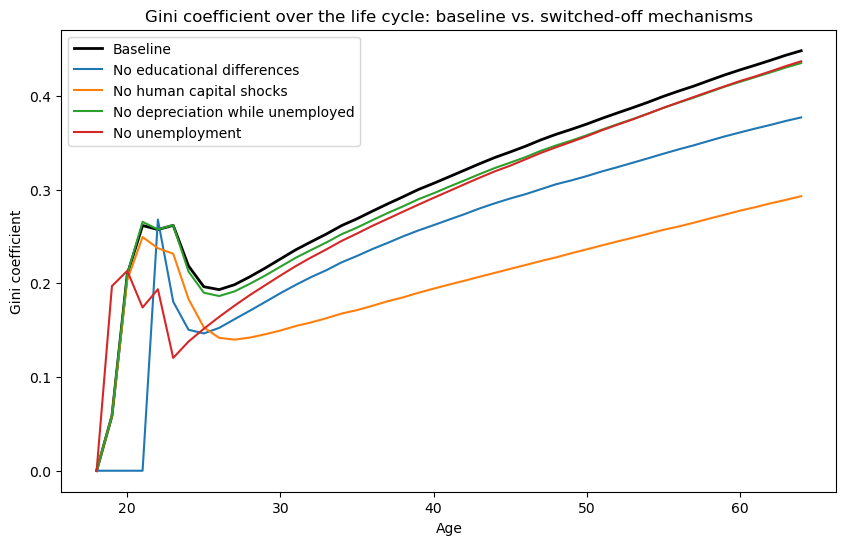

In [123]:
plt.figure(figsize=(10, 6))
for name, y in scenarios.items():
    if name == 'Baseline':
        plt.plot(sim.ages, sim.gini_by_age(y), label=name, color='black',
                 linewidth=2)
    else:
        plt.plot(sim.ages, sim.gini_by_age(y), label=name)

plt.xlabel('Age')
plt.ylabel('Gini coefficient')
plt.title('Gini coefficient over the life cycle: baseline vs. '
          'switched-off mechanisms')
plt.legend()
plt.show()

In the case of no depreciation of human capital while unemployed (green line), the results show that the Gini coefficient across the entire population increases, while it is lower than or equal to the baseline case within every age group. This is likely caused by the increased difference between younger and older age groups, since the lack of depreciation means older workers now simply accumulate more human capital on average.

## Exercise 2.5: Risk of injury

To mimic the fact that less educated people more often than highly educated people do physical work, we augment the model by adding a risk of injury while working. In this case, human capital depreciates at a faster rate, but the worker keeps the salary from just before the injury. Note that once the worker returns to the labour market, they are again compensated relative to their level of human capital.

Since employment now has three states, this is a separate simulation function in the module: `simulate_income_injury`.

We set delta_injury = 0.1, the chance of recovery to 0.95, and the risk of injury to (0.05, 0.02, 0.01) by education, so that the short-educated face the highest risk.

In [124]:
p_injury_e = np.array([0.05, 0.02, 0.01]) # chance of getting injured
p_recovery = 0.95 # change to recover from injury
delta_injury = 0.1 # depreciation while injured

uniforms_injury = rng.uniform(0.0, 1.0, size=(sim.N, sim.n_years))

income_injury, human_capital_injury = sim.simulate_income_injury(
    S_e_i, uniforms_injury, psi, education_level_i,
    p_injury_e=p_injury_e, p_recovery=p_recovery,
    delta_injury=delta_injury)

gini_full_injury = sim.gini_coefficient(income_injury.flatten())
print(f'Gini coefficient (injury risk extension, full sample): 'f'{gini_full_injury:.4f}')
print(f'Gini coefficient (baseline, full sample): 'f'{gini_full_sample:.4f}')

Gini coefficient (injury risk extension, full sample): 0.3784
Gini coefficient (baseline, full sample): 0.3742


We find that the addition of potential injury increases inequality, however only slightly.

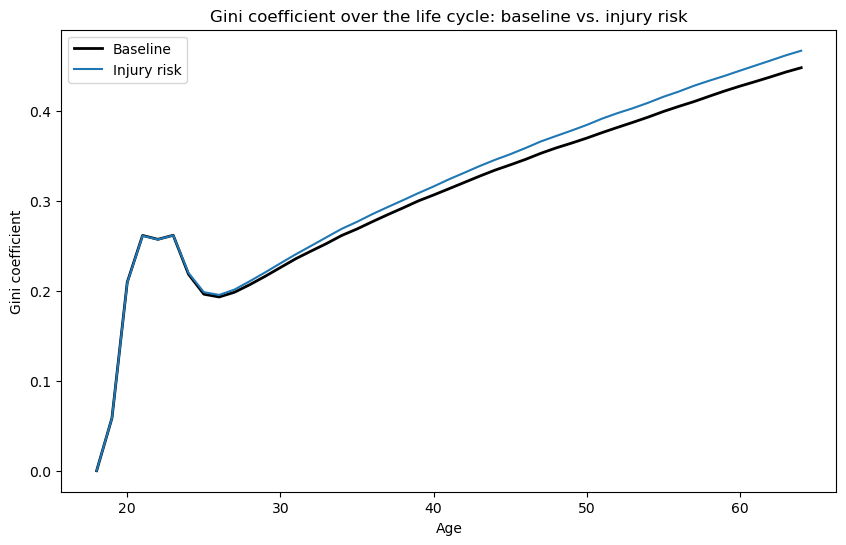

In [125]:
plt.figure(figsize=(10, 6))
plt.plot(sim.ages, gini_by_age_baseline, label='Baseline', color='black',
         linewidth=2)
plt.plot(sim.ages, sim.gini_by_age(income_injury), label='Injury risk')

plt.xlabel('Age')
plt.ylabel('Gini coefficient')
plt.title('Gini coefficient over the life cycle: baseline vs. injury risk')
plt.legend()
plt.show()

In [ ]:
# mean income by education, with and without injury risk
print(f'{"education":<10s}{"baseline":>10s}{"injury":>10s}{"pct":>8s}')
for e in range(3):
    keep = education_level_i == e
    y_base = income[keep].mean()
    y_injury = income_injury[keep].mean()
    pct = 100 * (y_injury / y_base - 1)
    print(f'{sim.educations[e]:<10s}{y_base:>10.4f}{y_injury:>10.4f}'
          f'{pct:>8.2f}')

education   baseline    injury     pct
short         1.0177    0.9180   -9.79
medium        1.4534    1.3904   -4.33
long          2.1777    2.1209   -2.61


Calculting the mean income for each education level in both cases shows that all levels of education are affected negatively by the introduction of risk of injury due to less human capital accumulation. However, it shows that individuals with short education are affected the most, which makes sense as they are the most prone to injuries.